In [1]:
!pip install numpy matplotlib scikit-learn

  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 1.6 MB/s eta 0:00:08
   -- ------------------------------------- 0.8/12.6 MB 1.4 MB/s eta 0:00:09
   --- ------------------------------------ 1.0/12.6 MB 1.5 MB/s eta 0:00:08
   ---- ----------------------------------- 1.6/12.6 MB 1.6 MB/s eta 0:00:07
   ----- ---------------------------------- 1.8/12.6 MB 1.6 MB/s eta 0:00:07
   ------- -------------------------------- 2.4/12.6 MB 1.8 MB/s eta 0:00:06
   --------- ------------------------------ 3.1/12.6 MB 2.0 MB/s eta 0:00:05
   ---------- ----------------------------- 3.4/12.6 MB 2.0 MB/s eta 0:00:05
   ------------ --------------------------- 3.9/12.6 MB 2.0 MB/s eta 0:00:05
   -------------- ------------------------- 4.5/12.6 MB 2.1 MB/s eta 0:00:04
   ----------------- ------

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


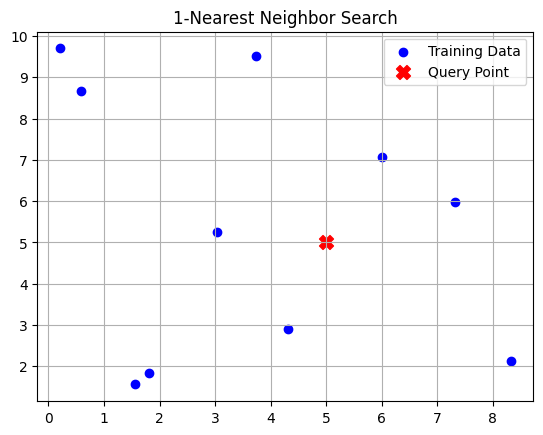

In [3]:
# Generate 10 random 2D points as training data
np.random.seed(42)
X_train = np.random.rand(10, 2) * 10  # Scale to range [0,10]

# Define a query point
query_point = np.array([[5, 5]])

# Plot the training points
plt.scatter(X_train[:, 0], X_train[:, 1], color='blue', label="Training Data")
plt.scatter(query_point[:, 0], query_point[:, 1], color='red', marker="X", s=100, label="Query Point")
plt.title("1-Nearest Neighbor Search")
plt.legend()
plt.grid()
plt.show()


In [4]:
# Compute Euclidean distance manually
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

# Find the nearest neighbor
closest_point = None
closest_distance = float("inf")

for point in X_train:
    distance = euclidean_distance(point, query_point[0])
    if distance < closest_distance:
        closest_distance = distance
        closest_point = point

print(f"Nearest Neighbor (Manual): {closest_point}, Distance: {closest_distance}")


Nearest Neighbor (Manual): [3.04242243 5.24756432], Distance: 1.9731695403252687


In [5]:
# Initialize NearestNeighbors model
nn_model = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn_model.fit(X_train)

# Find the nearest neighbor using scikit-learn
distances, indices = nn_model.kneighbors(query_point)

# Get the closest point
nn_sklearn = X_train[indices[0][0]]

print(f"Nearest Neighbor (scikit-learn): {nn_sklearn}, Distance: {distances[0][0]}")


Nearest Neighbor (scikit-learn): [3.04242243 5.24756432], Distance: 1.9731695403252687


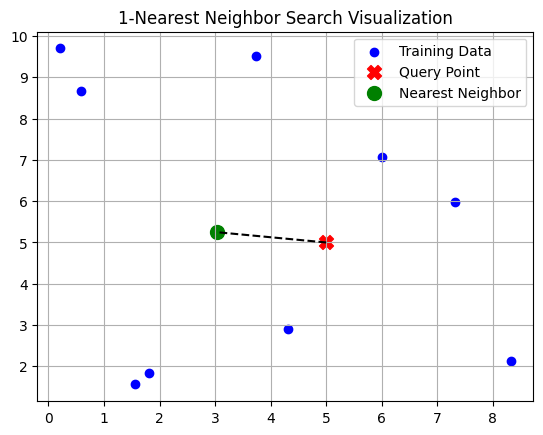

In [6]:
# Plot data
plt.scatter(X_train[:, 0], X_train[:, 1], color='blue', label="Training Data")
plt.scatter(query_point[:, 0], query_point[:, 1], color='red', marker="X", s=100, label="Query Point")
plt.scatter(nn_sklearn[0], nn_sklearn[1], color='green', marker="o", s=100, label="Nearest Neighbor")

# Draw a line connecting the query point to its nearest neighbor
plt.plot([query_point[0][0], nn_sklearn[0]], [query_point[0][1], nn_sklearn[1]], 'k--')

plt.title("1-Nearest Neighbor Search Visualization")
plt.legend()
plt.grid()
plt.show()
